In [63]:
# load json
import json
import networkx as nx
import matplotlib.pyplot as plt


In [64]:

with open("wiki_data_yearly_triples.json", 'r') as f:
    data = json.load(f)

In [65]:
def build_graph(triples):
    G = nx.Graph()

    triples_to_draw = [(h["head"], h["relation"], h["tail"], h["start"], h["end"]) for h in triples]

    for h, r, t, start, end in triples_to_draw:
        h_text = h
        t_text = t
        r_text = r

        edge_label = f"{r_text}\n[{start[:4]}–{end[:4]}]"
        G.add_edge(h_text, t_text, relation=edge_label)

    return G


def largest_component(G):
    if G.number_of_nodes() == 0:
        return G

    comp = max(nx.connected_components(G), key=len)
    G_sub = G.subgraph(comp).copy()

    return G_sub


def visualize(G, title):
    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42)

    nx.draw_networkx_nodes(G, pos, node_size=500)
    nx.draw_networkx_edges(G, pos, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=7)

    edge_labels = nx.get_edge_attributes(G, "relation")
    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=6,
        rotate=False,
    )

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



In [66]:
# put year as string
year = "1945"
time_step = data[year]

In [67]:
print(time_step)

[{'head': 'Osny', 'relation': 'located in the administrative territorial entity', 'tail': 'Seine-et-Oise', 'start': '1790-##-##', 'end': '1968-##-##'}, {'head': 'Rolleboise', 'relation': 'located in the administrative territorial entity', 'tail': 'Seine-et-Oise', 'start': '1790-##-##', 'end': '1968-##-##'}, {'head': 'Gödöllő District', 'relation': 'located in the administrative territorial entity', 'tail': 'Pest-Pilis-Solt-Kiskun County', 'start': '1898-##-##', 'end': '1950-##-##'}, {'head': 'Carrières-sous-Poissy', 'relation': 'located in the administrative territorial entity', 'tail': 'Seine-et-Oise', 'start': '1790-##-##', 'end': '1968-##-##'}, {'head': 'Villeneuve-Saint-Georges', 'relation': 'located in the administrative territorial entity', 'tail': 'Seine-et-Oise', 'start': '1790-##-##', 'end': '1968-##-##'}, {'head': 'Riga', 'relation': 'located in the administrative territorial entity', 'tail': 'Latvian Soviet Socialist Republic', 'start': '1944-##-##', 'end': '1990-##-##'}, {'

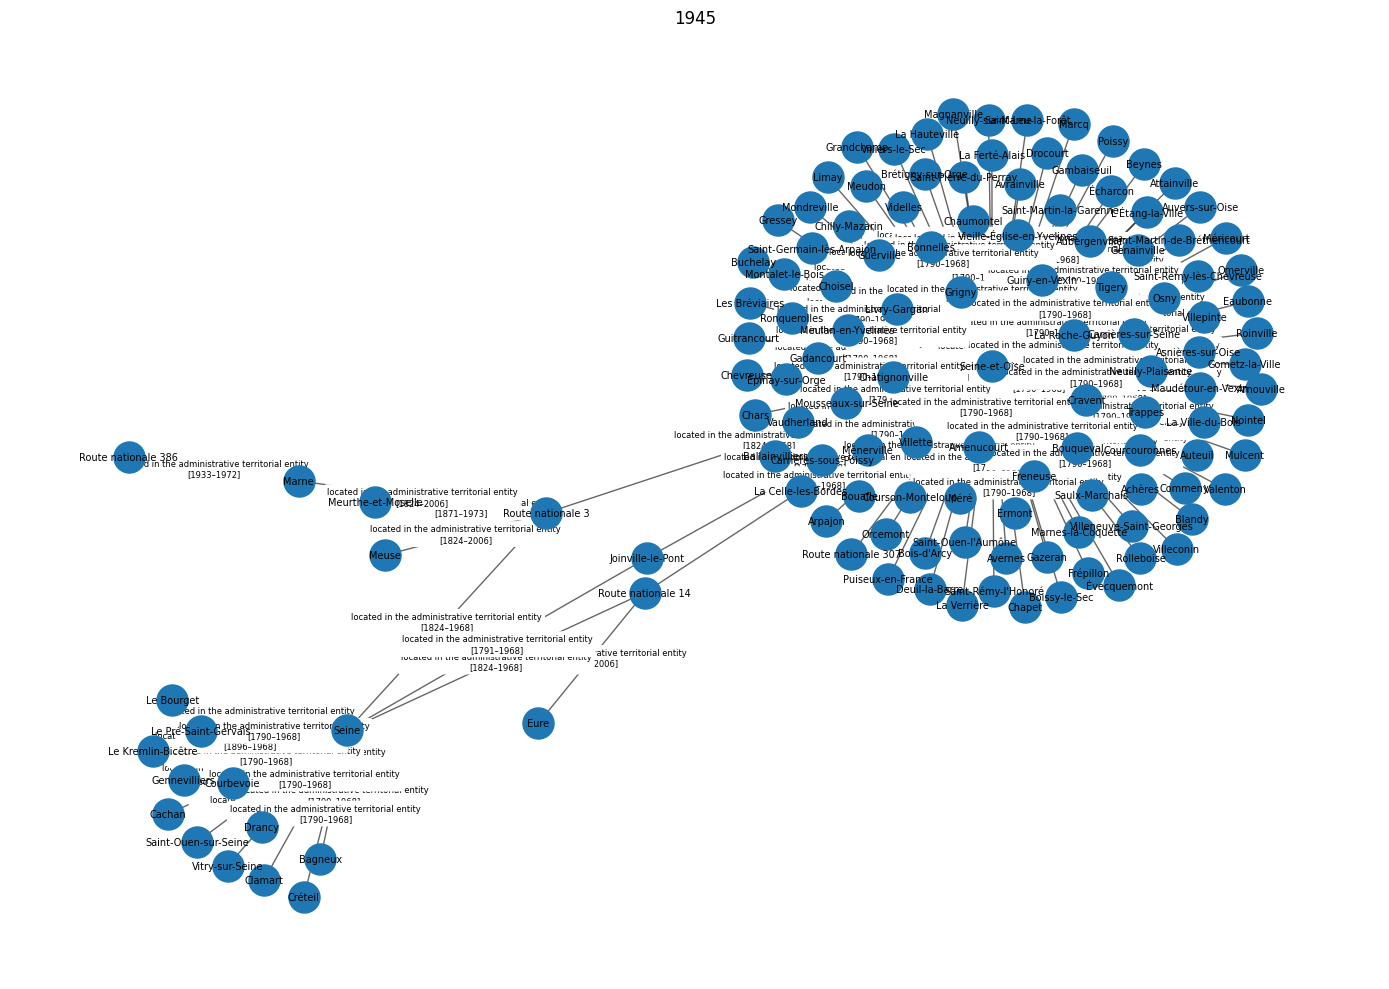

In [68]:
G = build_graph(time_step)
G = largest_component(G)
visualize(G, year)